# Ideas / todo:

- Improve the detection in z

- Show how well a CNN with the exact same architecure can perform without a trainable phase mask, and compare the results (to make it clear why the trainable phase mask is needed).

- Why is a hardtanh better than for example a sigmoid activation at the end of the network?

- add the postprocessing (to interpret the results similar to how they did it)

# Particle localization and phase mask optimization

This tutorial demonstrates how to optimize a phase mask to improve localization of closely spaced particles. The localization is performed by a convolutional neural network (CNN), trained jointly with the phase mask to improve both the optical setup and the network performance.

# 1. Create a simulation pipeline

In [ ]:
import sys

sys.path.insert(0, '/Users/xgrmir/Documents/DeepTrack2/DeepTrack2')

import deeptrack as dt
print(dt.__file__)

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


c:\Users/xgrmir/Documents/DeepTrack2/DeepTrack2\deeptrack\__init__.py


C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\kornia\feature\lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
c:\Users/xgrmir/Documents/DeepTrack2/DeepTrack2\deeptrack\__init__.py:13: UserWarning: TensorFlow is detected in your environment. DeepTrack2 version 2.0++ no longer supports TensorFlow. If you need TensorFlow support, please install the legacy version 1.7 of DeepTrack2:

    pip install deeptrack==1.7

For more details, refer to the DeepTrack documentation.
  warnings.warn(


## 1.1 Set the backend

In [2]:
from deeptrack.backend import config

config.set_backend("torch")
config.set_device("cuda")

device = config.get_device()

print(config.get_backend(), config.get_device())

torch cuda


## 1.2 Define the trainable phase mask

I don't know if inheriting from both nn.Module and dt.Aberration is correct?

In [3]:
import torch
import torch.nn as nn

class LearnablePhaseMask(nn.Module, dt.Aberration):
    """Applies a learnable phase mask to the pupil function."""

    def __init__(self, shape=(144, 144), **kwargs):
        dt.Aberration.__init__(self, **kwargs)
        super().__init__(**kwargs)
        
        # Create a torch parameter for the phase
        self.phase = nn.Parameter(torch.zeros(shape, dtype=torch.float32))
        # self.phase = nn.Parameter(torch.randn(shape, dtype=torch.float32))

    def forward(self, pupil: torch.Tensor, **kwargs) -> torch.Tensor:
        """PyTorch forward pass"""
        return self.apply_phase(pupil)

    def get(self, pupil: torch.Tensor, **kwargs) -> torch.Tensor:
        """DeepTrack Feature graph call"""
        return self.apply_phase(pupil)

    def apply_phase(self, pupil: torch.Tensor) -> torch.Tensor:
        """Shared implementation"""
        phase = self.phase.to(device)
        phase_mask = torch.cos(phase) + 1j * torch.sin(phase)
        return pupil * phase_mask

## 1.3 Define the optical setup

In [4]:
image_size = 121
depth = 20

In [5]:
phase_mask = LearnablePhaseMask()

optics = dt.Fluorescence(
    NA=1.45,
    refractive_index_medium=1.33,   
    output_region=(0,0, image_size, image_size),
    pupil=phase_mask,
)

## 1.4 Simulate particles

In [6]:
import matplotlib.pyplot as plt

### Random positions in 3D, and gt in 3D:

In [7]:
class Positions(dt.Feature):
    def get(self, image, num_points, **kwargs):
        mask = torch.zeros((image.shape[0], image.shape[1], image.shape[2]), dtype=float)

        points = torch.rand(size=(num_points, 3)) * torch.tensor(image.shape)

        for i in range(len(points)):
            mask[
                torch.round(points[i, 0]).long().clamp(0, image.shape[0]-1),
                torch.round(points[i, 1]).long().clamp(0, image.shape[1]-1),
                torch.round(points[i, 2]).long().clamp(0, image.shape[2]-1)
            ] = 1

        self.points = points

        return mask + image

In [8]:
num_points = lambda: int(torch.randint(low=5, high=20, size=(1,)))
xyz = Positions(num_points=num_points)

In [9]:
i = -1
def next_position():
    global i
    gt_pip.resolve()
    i = (i + 1) % len(xyz.points)
    return xyz.points[i]

particle = dt.PointParticle(position=next_position)

gt_pip = dt.Value(torch.zeros((image_size, image_size, depth), dtype=float)) >> xyz
im_pip = optics(particle ^ num_points)

pip = (im_pip & gt_pip) >> dt.MoveAxis(2, 0)

In [10]:
pip.update()
im, gt = pip.resolve()

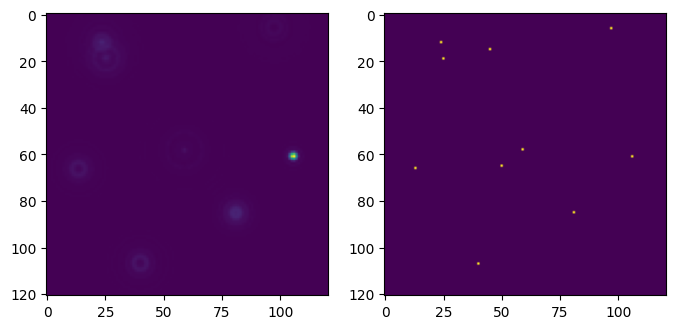

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(8,4))

axs[0].imshow(im[0].cpu().detach().numpy())
axs[1].imshow(gt.max(dim=0)[0])

In [12]:
# plt.imshow(im[0].cpu().detach().numpy())
# plt.scatter(xyz.points[:, 1], xyz.points[:, 0], c='red')

## 2. Defining the CNN

In [13]:
import deeplay as dl

class CNNConcat(dl.ConvolutionalNeuralNetwork):
    def forward(self, input):
        out = None

        for idx, block in enumerate(self.blocks):

            if idx == 0:
                out = block(input)

            elif idx < len(self.blocks) - 1:
                features = torch.cat((out, input), dim=1)
                new_out = block(features)
                out = new_out + out

            else:
                out = block(out)

        return out

In [14]:
hidden_dim = 64
factor = 10.0

CNN = CNNConcat(
    in_channels=1,
    hidden_channels=[hidden_dim + 1] * 8 + [hidden_dim],
    out_channels=depth,
)

CNN["blocks", "0"].prepend(
    dl.Layer(torch.nn.BatchNorm2d, num_features=1),
    name="initial_normalization",
)
CNN[..., "activation"].all.configure(
    nn.LeakyReLU, negative_slope=0.2, inplace=True
)
CNN[...].isinstance(dl.Conv2dBlock).all.normalized(torch.nn.BatchNorm2d)
CNN[..., "normalization"].all.configure(num_features=hidden_dim)

CNN[..., "layer#:-1"].configure(out_channels=hidden_dim)

CNN["blocks", "9"].remove("normalization", allow_missing=True)
CNN[..., "activation#-1"].configure(nn.Hardtanh, min_val=0.0, max_val=factor)

In [15]:
cnn = CNN.create()

cnn.to(device)
print(cnn)

CNNConcat(
  (blocks): LayerList(
    (0): Conv2dBlock(
      (initial_normalization): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (layer): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.2, inplace=True)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1-8): 8 x Conv2dBlock(
      (layer): Conv2d(65, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.2, inplace=True)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (9): Conv2dBlock(
      (layer): Conv2d(64, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (activation): Hardtanh(min_val=0.0, max_val=10.0, inplace=True)
    )
  )
)


Check that the outputs of the cnn, and the targets have the same shape:

In [16]:
images, gt = [], []
for _ in range(2):
    pip.update()
    img, g = pip.resolve()
    images.append(img)
    gt.append(g)

images = torch.stack(images)
gt = torch.stack(gt).to(device, dtype=torch.float32)

preds = cnn(images)
print("Preds:", preds.shape)
print("Target:", gt.shape)

Preds: torch.Size([2, 20, 121, 121])
Target: torch.Size([2, 20, 121, 121])


### 2.2 Loss function of DeepSTORM 3D:

In [17]:
import numpy as np
import torch.nn.functional as F

def dice_loss(pred, target):
    """
    This definition generalize to real valued pred and target vector.
    pred: tensor with first dimension as batch
    target: tensor with first dimension as batch
    """

    smooth = 1.

    # have to use contiguous since they may from a torch.view op
    iflat = pred.contiguous().view(-1)
    tflat = target.contiguous().view(-1)
    intersection = (iflat * tflat).sum()

    A_sum = torch.sum(iflat * iflat)
    B_sum = torch.sum(tflat * tflat)


    return 1 - ((2. * intersection + smooth) / (A_sum + B_sum + smooth))


# create a 3D gaussian kernel
# def GaussianKernel(shape=(7, 7, 7), sigma=1, normfactor=1):
def GaussianKernel(shape=(3, 3, 3), sigma=0.25, normfactor=1):
# def GaussianKernel(shape=(5, 3, 3), sigma=(0.5, 0.1, 0.1), normfactor=1):
    """
    3D gaussian mask - should give the same result as MATLAB's
    fspecial('gaussian',[shape],[sigma]) in 3D
    """
    m, n, p = [(ss - 1.) / 2. for ss in shape]
    y, x, z = np.ogrid[-m:m + 1, -n:n + 1, -p:p + 1]
    h = np.exp(-(x * x + y * y + z * z) / (2 * sigma ** 2))
    # sigma_D, sigma_H, sigma_W = sigma
    # h = np.exp(-( (z**2)/(2*sigma_D**2) + (y**2)/(2*sigma_H**2) + (x**2)/(2*sigma_W**2) ))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    """
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
        h = h * normfactor
    """
    maxh = h.max()
    if maxh != 0:
        h /= maxh
        h = h * normfactor
    h = torch.from_numpy(h).type(torch.FloatTensor)
    h = h.unsqueeze(0)
    h = h.unsqueeze(1)
    return h


# define the 3D extended loss function from DeepSTORM
class KDE_loss3D(nn.Module):
    def __init__(self, factor, device):
        super(KDE_loss3D, self).__init__()
        self.kernel = GaussianKernel().to(device)
        self.factor = factor

    def forward(self, pred_bol, target_bol):

        # extract kernel dimensions
        N, C, D, H, W = self.kernel.size()
        
        # extend prediction and target to have a single channel
        target_bol = target_bol.unsqueeze(1)
        pred_bol = pred_bol.unsqueeze(1)

        # KDE for both input and ground truth spikes
        Din = F.conv3d(pred_bol, self.kernel, padding=(int(np.round((D - 1) / 2)), 0, 0))
        Dtar = F.conv3d(target_bol, self.factor*self.kernel, padding=(int(np.round((D - 1) / 2)), 0, 0))

        # kde loss
        kde_loss = nn.MSELoss()(Din, Dtar)      # add a higher weight for the z-loss?
        
        # final loss
        final_loss = kde_loss + dice_loss(pred_bol/self.factor, target_bol)

        return final_loss

In [18]:
# loss function
loss_fn = KDE_loss3D(factor=factor, device=device)

### 2.3 Optimizer
For both the CNN and the phase mask

In [19]:
optimizer = torch.optim.Adam(
    list(phase_mask.parameters()) + list(cnn.parameters()),
    lr=1e-3
)

## 3. Training the CNN and the phase mask

### 3.1 Visualize the phase mask before training

0.0 0.0 0.0


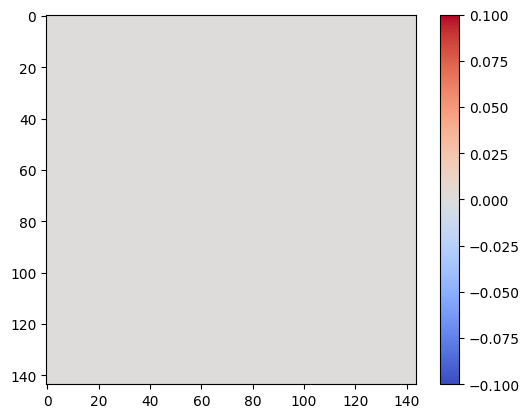

In [20]:
phase_mask_before = phase_mask.phase.cpu().detach().clone()
print(phase_mask.phase.min().item(), phase_mask.phase.max().item(), phase_mask.phase.mean().item())

plt.imshow(phase_mask_before, cmap='coolwarm')
plt.colorbar()
plt.show();

### 3.2 Training the phase mask and CNN together using a custom training loop

Explain here that we need to update the simulation pipline each epoch to be able to update the phase mask during training.

In [21]:
num_epochs = 500
batch_size = 10
loss_history = []

for epoch in range(num_epochs):
    cnn.train()

    images, gt = [], []
    for _ in range(batch_size):
        pip.update()
        img, g = pip.resolve()
        images.append(img)
        gt.append(g)

    images = torch.stack(images)
    gt = torch.stack(gt).to(device, dtype=torch.float32)

    optimizer.zero_grad(set_to_none=True)
    preds = cnn(images)
    loss = loss_fn(preds, gt)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.detach().cpu().item())

    print(f"Epoch {epoch}, Loss: {loss.detach().cpu().item():.4f}")

Epoch 0, Loss: 1.5664
Epoch 1, Loss: 1.3561
Epoch 2, Loss: 1.2311
Epoch 3, Loss: 1.1660
Epoch 4, Loss: 1.0746
Epoch 5, Loss: 1.0634
Epoch 6, Loss: 1.0438
Epoch 7, Loss: 1.0271
Epoch 8, Loss: 1.0235
Epoch 9, Loss: 0.9918
Epoch 10, Loss: 0.9965
Epoch 11, Loss: 0.9952
Epoch 12, Loss: 0.9815
Epoch 13, Loss: 0.9984
Epoch 14, Loss: 0.9773
Epoch 15, Loss: 0.9592
Epoch 16, Loss: 0.9264
Epoch 17, Loss: 0.8997
Epoch 18, Loss: 0.8855
Epoch 19, Loss: 0.8930
Epoch 20, Loss: 0.8950
Epoch 21, Loss: 0.9032
Epoch 22, Loss: 0.9079
Epoch 23, Loss: 0.9136
Epoch 24, Loss: 0.9371
Epoch 25, Loss: 0.8959
Epoch 26, Loss: 0.8673
Epoch 27, Loss: 0.8815
Epoch 28, Loss: 0.9072
Epoch 29, Loss: 0.8677
Epoch 30, Loss: 0.8646
Epoch 31, Loss: 0.8878
Epoch 32, Loss: 0.9188
Epoch 33, Loss: 0.8780
Epoch 34, Loss: 0.8654
Epoch 35, Loss: 0.9076
Epoch 36, Loss: 0.8585
Epoch 37, Loss: 0.8689
Epoch 38, Loss: 0.8152
Epoch 39, Loss: 0.8506
Epoch 40, Loss: 0.8245
Epoch 41, Loss: 0.8069
Epoch 42, Loss: 0.8288
Epoch 43, Loss: 0.823

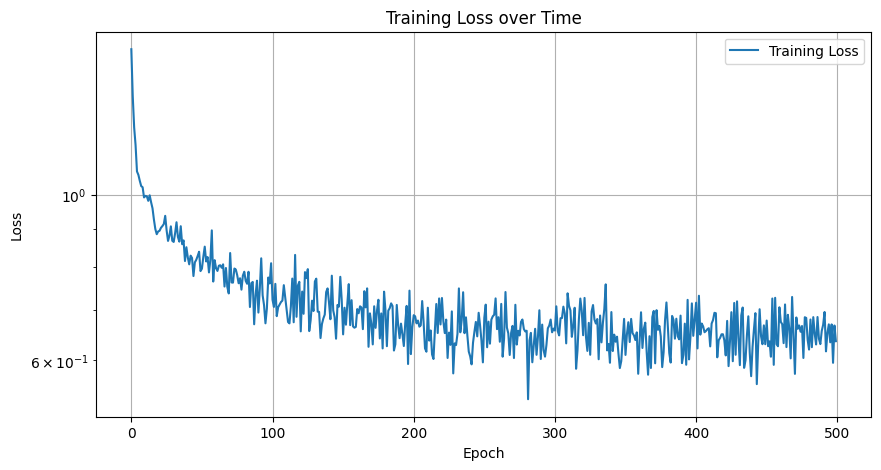

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), loss_history, label='Training Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.grid(True)
plt.legend()
plt.show()

### 3.3 Visualize the phase mask after training

-0.31498998403549194 0.3399564027786255 -0.000746103934943676


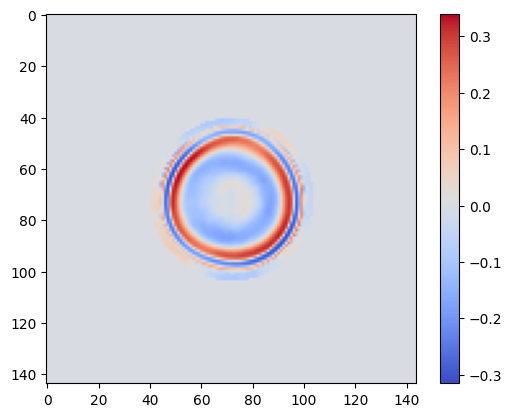

In [23]:
phase_mask_after = phase_mask.phase.cpu().detach().clone()
print(phase_mask.phase.min().item(), phase_mask.phase.max().item(), phase_mask.phase.mean().item())

plt.imshow(phase_mask_after, cmap='coolwarm')
plt.colorbar()
plt.show();

## 4. Post-processing
Copied from DeepSTORM3D

In [24]:
from torch.nn import Module, MaxPool3d, ConstantPad3d, MaxPool2d
from torch.nn.functional import conv3d

# convert gpu tensors to numpy
def tensor_to_np(x):
    return np.squeeze(x.detach().cpu().numpy())

# post-processing on GPU: thresholding and local maxima finding
class Postprocess(Module):
    def __init__(self, device, thresh=40, radius=4, keep_singlez=False):
        super().__init__()
        self.device = device
        self.thresh = thresh
        self.r = radius
        self.keep_singlez = keep_singlez
        self.maxpool = MaxPool3d(kernel_size=2*self.r + 1, stride=1, padding=self.r)
        self.maxpool2 = MaxPool2d(kernel_size=2*self.r + 1, stride=1, padding=self.r)
        self.pad = ConstantPad3d(self.r, 0.0)
        self.zero = torch.FloatTensor([0.0]).to(self.device)

        # construct the local average filters
        filt_vec = np.arange(-self.r, self.r + 1)
        yfilter, zfilter, xfilter = np.meshgrid(filt_vec, filt_vec, filt_vec)
        xfilter = torch.FloatTensor(xfilter).unsqueeze(0).unsqueeze(0)
        yfilter = torch.FloatTensor(yfilter).unsqueeze(0).unsqueeze(0)
        zfilter = torch.FloatTensor(zfilter).unsqueeze(0).unsqueeze(0)
        sfilter = torch.ones_like(xfilter)
        self.local_filter = torch.cat((sfilter, xfilter, yfilter, zfilter), 0).to(self.device)

    def keep_maxz(self, conf_vol):

        # get the maximum value in z per xy
        D, H, W = conf_vol.shape
        max_proj, _ = torch.max(conf_vol, dim=0, keepdim=True)

        # keep only local maxima in 2d
        max_proj = self.maxpool2(max_proj.unsqueeze(0))
        max_proj = max_proj.squeeze(0)

        # keep only maximum
        conf_vol_out = torch.where(conf_vol == max_proj.expand(D, H, W), conf_vol, self.zero)

        return conf_vol_out
    
    def local_avg(self, xbool, ybool, zbool, pred_vol_pad, num_pts, device):

        # create the concatenated tensor of all local volumes
        pred_vol_all = torch.zeros(num_pts, 1, self.r*2 + 1, self.r*2 + 1, self.r*2 + 1).to(device)
        for pt in range(num_pts):

            # local 3D volume
            xpt = [xbool[pt], xbool[pt] + 2 * self.r + 1]
            ypt = [ybool[pt], ybool[pt] + 2 * self.r + 1]
            zpt = [zbool[pt], zbool[pt] + 2 * self.r + 1]
            pred_vol_all[pt, :] = pred_vol_pad[:, :, zpt[0]:zpt[1], ypt[0]:ypt[1], xpt[0]:xpt[1]]

        # convolve it using conv3d
        sums = conv3d(pred_vol_all, self.local_filter)

        # squeeze the sums and convert them to local perturbations
        xloc = sums[:, 1] / sums[:, 0]
        yloc = sums[:, 2] / sums[:, 0]
        zloc = sums[:, 3] / sums[:, 0]

        return xloc, yloc, zloc

    def forward(self, pred_vol):

        # check size of the prediction and expand it accordingly to be 5D
        num_dims = len(pred_vol.size())
        if np.not_equal(num_dims, 5):
            if num_dims == 4:
                pred_vol = pred_vol.unsqueeze(0)
            else:
                pred_vol = pred_vol.unsqueeze(0)
                pred_vol = pred_vol.unsqueeze(0)

        # apply the threshold
        pred_thresh = torch.where(pred_vol > self.thresh, pred_vol, self.zero)

        # apply the 3D maxpooling operation to find local maxima
        conf_vol = self.maxpool(pred_thresh)
        conf_vol = torch.where((conf_vol > self.zero) & (conf_vol == pred_thresh), conf_vol, self.zero)
        
        # keep only a single z in each xy sub-pixel
        if self.keep_singlez:
            conf_vol = torch.squeeze(conf_vol)
            conf_vol = self.keep_maxz(conf_vol)

        # find locations of confs (bigger than 0)
        conf_vol = torch.squeeze(conf_vol)
        batch_indices = torch.nonzero(conf_vol)
        zbool, ybool, xbool = batch_indices[:, 0], batch_indices[:, 1], batch_indices[:, 2]

        # if the prediction is empty return None otherwise convert to list of locations
        if len(zbool) == 0:
            xyz_rec = None
            conf_rec = None

        else:

            # pad the result with radius_px 0's for average calc.
            pred_vol_pad = self.pad(pred_vol)

            # for each point calculate local weighted average
            num_pts = len(zbool)
            xloc, yloc, zloc = self.local_avg(xbool, ybool, zbool, pred_vol_pad, num_pts, self.device)

            # convert lists and tensors to numpy
            xloc, yloc, zloc = tensor_to_np(xloc), tensor_to_np(yloc), tensor_to_np(zloc)
            xbool, ybool, zbool = tensor_to_np(xbool), tensor_to_np(ybool), tensor_to_np(zbool)

            # calculate the recovered positions assuming mid-voxel
            xrec = xbool + xloc
            yrec = ybool + yloc            
            zrec = zbool + zloc

            # rearrange the result into a Nx3 array
            xyz_rec = np.column_stack((xrec, yrec, zrec))

            # confidence of these positions
            conf_rec = conf_vol[zbool, ybool, xbool]
            conf_rec = tensor_to_np(conf_rec)

        return xyz_rec, conf_rec

In [25]:
radius = 2
threshold = 1

postprocessing_module = Postprocess(device, thresh=threshold, radius=radius, keep_singlez=True)

## 5. Check the performance of the combination of the optimized optical setup and the CNN

In [26]:
def jaccard_coeff(pred, target):
    """
    jaccard index = TP / (TP + FP + FN)
    pred: tensor with first dimension as batch
    target: tensor with first dimension as batch
    """

    # smoothing parameter
    smooth = 1e-6
    
    # number of examples in the batch
    N = pred.size(0)

    # have to use contiguous since they may from a torch.view op
    iflat = pred.contiguous().view(N,-1)
    tflat = target.contiguous().view(N,-1)
    intersection = (iflat * tflat).sum(1)
    jacc_index = (intersection / (iflat.sum(1) + tflat.sum(1) - intersection + smooth)).mean()

    return jacc_index

In [27]:
num_tests = 40
jaccard_index = []
jaccard_index_coords = []

for _ in range(num_tests):
    pip.update()
    img, g = pip.resolve()
    g = g.to(device)

    pred = cnn(img.unsqueeze(0))
    
    jaccard_index.append(jaccard_coeff(pred, g.unsqueeze(0)))

average_jaccard_index = torch.mean(torch.tensor(jaccard_index))
print(average_jaccard_index)

tensor(0.3988, dtype=torch.float64)


### 5.1 Plot the average over z

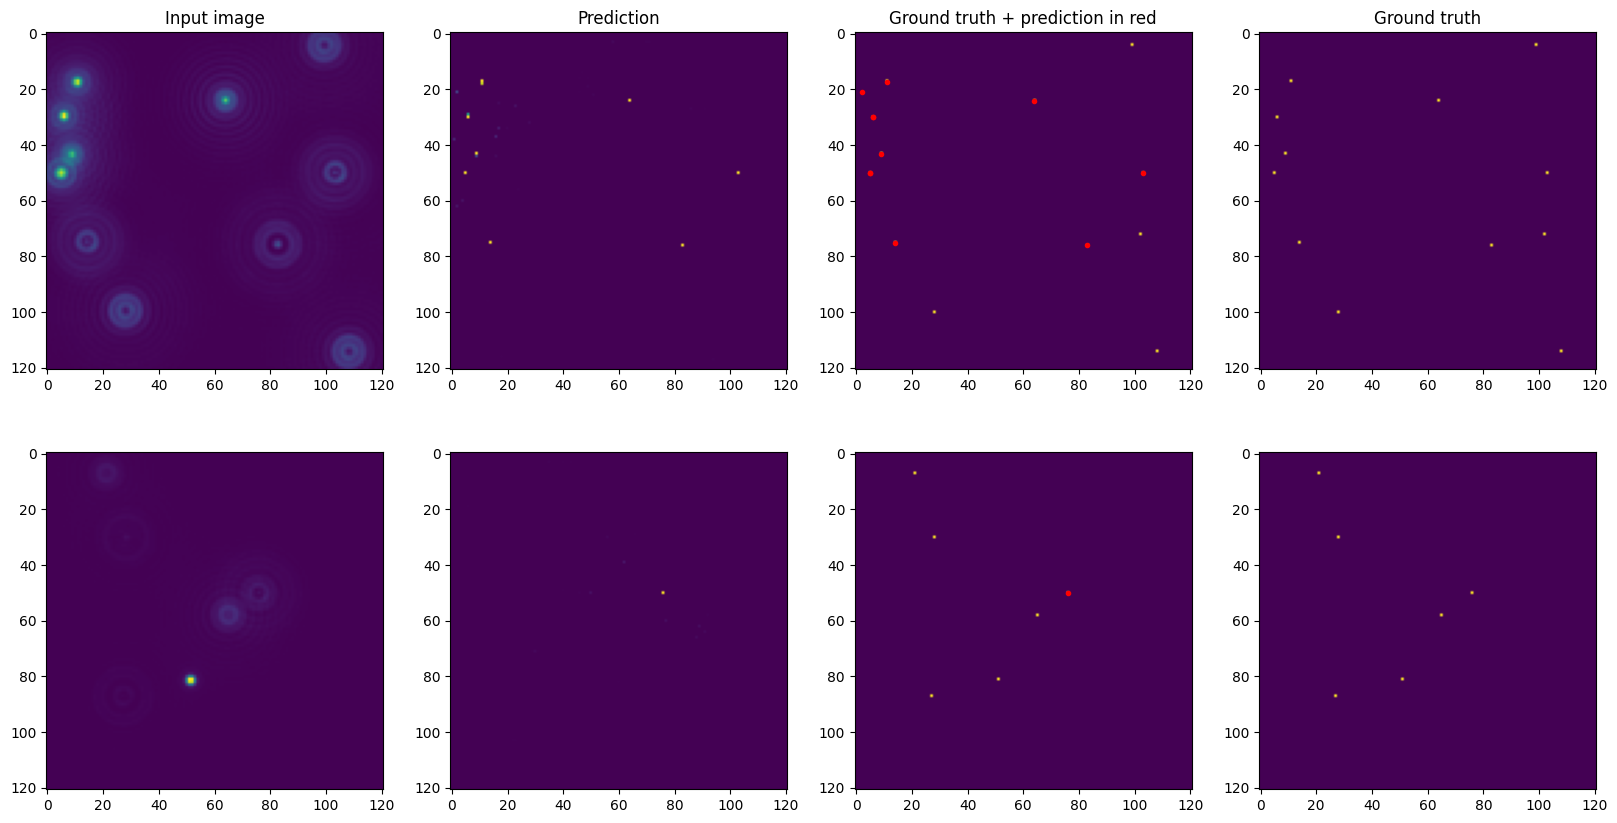

In [33]:
num_samples = 2
fig, ax = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))

images, gt = [], []
for _ in range(num_samples):
    pip.update()
    img, g = pip.resolve()
    images.append(img)
    gt.append(g)

images = torch.stack(images)
gt = torch.stack(gt)

preds = cnn(images)

for i in range(num_samples):

    xyz_rec, conf_rec = postprocessing_module(preds[i])
    xyz_target = torch.nonzero(gt[i])[:, [2,1,0]]

    ax[i, 0].imshow(images[i, 0].cpu().detach().numpy())
    ax[i, 1].imshow(preds[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].plot(xyz_rec[:, 0], xyz_rec[:,1], c='red', marker='.', ls=' ')
    ax[i, 3].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())

ax[0, 0].set_title("Input image")
ax[0, 1].set_title("Prediction")
ax[0, 2].set_title("Ground truth + prediction in red")
ax[0, 3].set_title("Ground truth");

### 5.2 Visualize the predicted positions in 3D

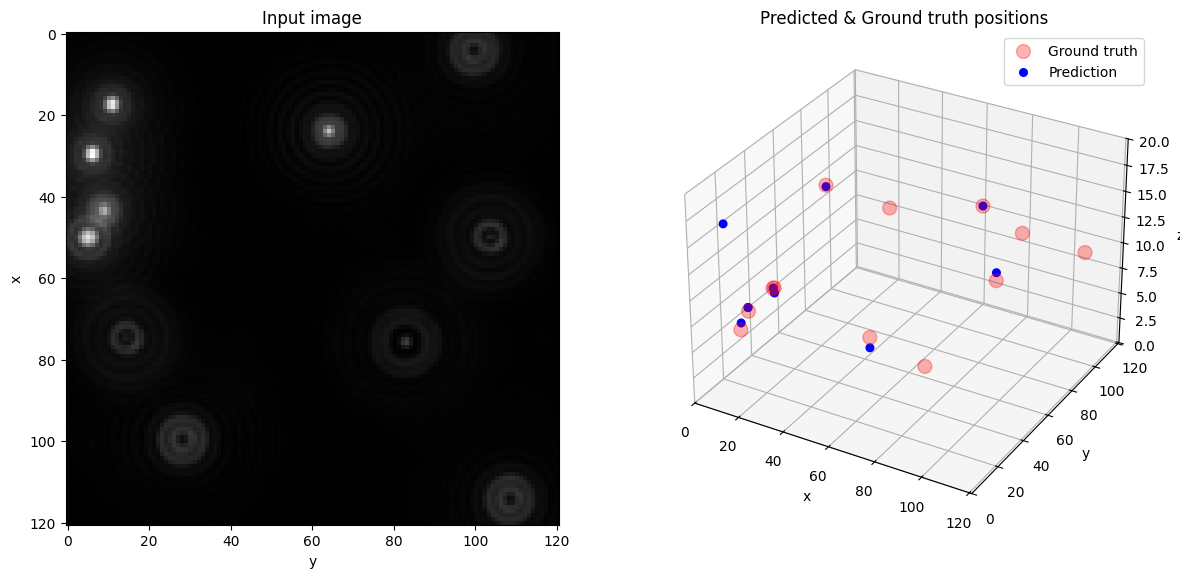

In [34]:
sample = 0

fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121)
ax1.imshow(images[sample, 0].cpu().detach().numpy(), cmap='gray')
ax1.set_xlabel("y")
ax1.set_ylabel("x")
ax1.set_title("Input image")


xyz_rec, conf_rec = postprocessing_module(preds[sample])
xyz_target = torch.nonzero(gt[sample])[:, [2,1,0]]

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(xyz_target[:, 0], xyz_target[:, 1], xyz_target[:, 2], c='red', marker='o', s=100, label='Ground truth', alpha=0.3)
ax2.scatter(xyz_rec[:, 0], xyz_rec[:, 1], xyz_rec[:, 2], c='blue', marker='o', s=30, label='Prediction', alpha=1)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.set_xlim(0, image_size)
ax2.set_ylim(0, image_size)
ax2.set_zlim(0, depth)
ax2.set_title('Predicted & Ground truth positions')
ax2.legend();

## 6. Compare with not having a trainable phase mask:

In [35]:
optics_no_phase_mask = dt.Fluorescence(
    NA=1.45,
    refractive_index_medium=1.33,   
    output_region=(0,0, image_size, image_size),
)

im_pip_no_phase_mask = optics_no_phase_mask(particle ^ num_points)

pip_no_phase_mask = (im_pip_no_phase_mask & gt_pip) >> dt.MoveAxis(2, 0)

In [36]:
cnn_no_phase_mask = CNN.create()
cnn_no_phase_mask.to(device)

optimizer_no_phase_mask = torch.optim.Adam(list(cnn_no_phase_mask.parameters()), lr=1e-3)

In [37]:
loss_history = []

for epoch in range(num_epochs):
    cnn_no_phase_mask.train()

    images, gt = [], []
    for _ in range(batch_size):
        pip_no_phase_mask.update()
        img, g = pip_no_phase_mask.resolve()
        images.append(img)
        gt.append(g)

    images = torch.stack(images)
    gt = torch.stack(gt).to(device, dtype=torch.float32)

    optimizer_no_phase_mask.zero_grad(set_to_none=True)
    preds = cnn_no_phase_mask(images)
    loss = loss_fn(preds, gt)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.detach().cpu().item())

    print(f"Epoch {epoch}, Loss: {loss.detach().cpu().item():.4f}")

Epoch 0, Loss: 1.5635
Epoch 1, Loss: 1.5414
Epoch 2, Loss: 1.5977
Epoch 3, Loss: 1.6352
Epoch 4, Loss: 1.5143
Epoch 5, Loss: 1.6286
Epoch 6, Loss: 1.6462
Epoch 7, Loss: 1.6053
Epoch 8, Loss: 1.5481
Epoch 9, Loss: 1.6548
Epoch 10, Loss: 1.4573
Epoch 11, Loss: 1.6242
Epoch 12, Loss: 1.5795
Epoch 13, Loss: 1.6447
Epoch 14, Loss: 1.4447
Epoch 15, Loss: 1.5271
Epoch 16, Loss: 1.5181
Epoch 17, Loss: 1.4815
Epoch 18, Loss: 1.4799
Epoch 19, Loss: 1.6273
Epoch 20, Loss: 1.5745
Epoch 21, Loss: 1.6112
Epoch 22, Loss: 1.5948
Epoch 23, Loss: 1.4881
Epoch 24, Loss: 1.6148
Epoch 25, Loss: 1.5935
Epoch 26, Loss: 1.5250
Epoch 27, Loss: 1.5502
Epoch 28, Loss: 1.5858
Epoch 29, Loss: 1.5297
Epoch 30, Loss: 1.5796
Epoch 31, Loss: 1.6924
Epoch 32, Loss: 1.6585
Epoch 33, Loss: 1.6205
Epoch 34, Loss: 1.5922
Epoch 35, Loss: 1.5979
Epoch 36, Loss: 1.6486
Epoch 37, Loss: 1.6068
Epoch 38, Loss: 1.5369
Epoch 39, Loss: 1.5174
Epoch 40, Loss: 1.4944
Epoch 41, Loss: 1.5770
Epoch 42, Loss: 1.6990
Epoch 43, Loss: 1.615

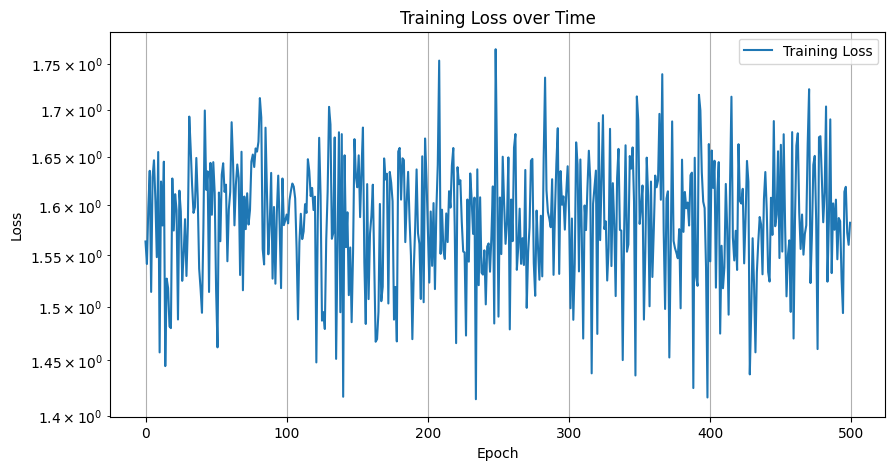

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), loss_history, label='Training Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.grid(True)
plt.legend()
plt.show()

In [39]:
jaccard_index = []
jaccard_index_coords = []

for _ in range(num_tests):
    pip_no_phase_mask.update()
    img, g = pip_no_phase_mask.resolve()
    g = g.to(device)

    pred = cnn_no_phase_mask(img.unsqueeze(0))
    
    jaccard_index.append(jaccard_coeff(pred, g.unsqueeze(0)))

average_jaccard_index = torch.mean(torch.tensor(jaccard_index))
print(average_jaccard_index)

tensor(0.0001, dtype=torch.float64)


In [40]:
threshold_no_phase_mask = 4

postprocessing_module_no_phase_mask = Postprocess(device, thresh=threshold_no_phase_mask, radius=radius, keep_singlez=True)

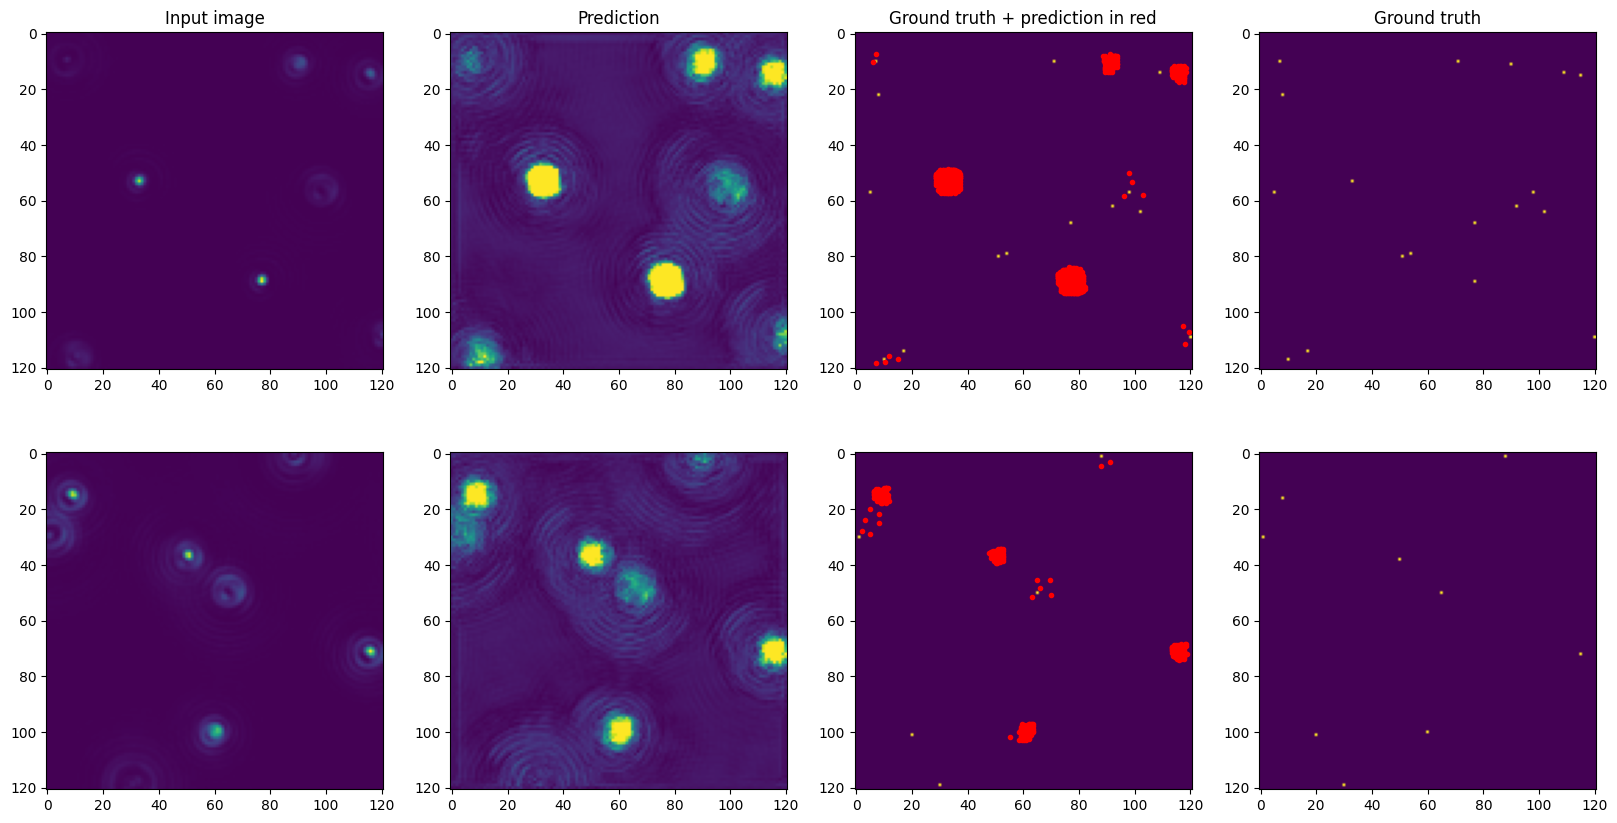

In [41]:
num_samples = 2
fig, ax = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))

images, gt = [], []
for _ in range(num_samples):
    pip_no_phase_mask.update()
    img, g = pip.resolve()
    images.append(img)
    gt.append(g)

images = torch.stack(images)
gt = torch.stack(gt)

preds = cnn_no_phase_mask(images)

for i in range(num_samples):

    xyz_rec, conf_rec = postprocessing_module_no_phase_mask(preds[i])
    xyz_target = torch.nonzero(gt[i])[:, [2,1,0]]

    ax[i, 0].imshow(images[i, 0].cpu().detach().numpy())
    ax[i, 1].imshow(preds[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())
    ax[i, 2].plot(xyz_rec[:, 0], xyz_rec[:,1], c='red', marker='.', ls=' ')
    ax[i, 3].imshow(gt[i].max(dim=0)[0].cpu().detach().numpy())

ax[0, 0].set_title("Input image")
ax[0, 1].set_title("Prediction")
ax[0, 2].set_title("Ground truth + prediction in red")
ax[0, 3].set_title("Ground truth");

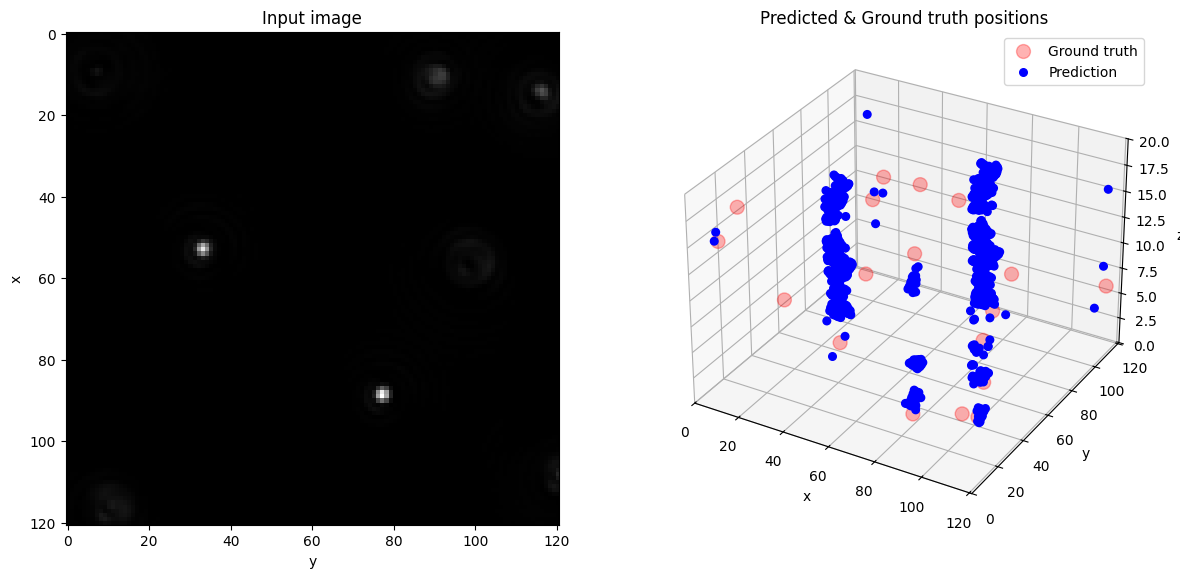

In [42]:
sample = 0

fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121)
ax1.imshow(images[sample, 0].cpu().detach().numpy(), cmap='gray')
ax1.set_xlabel("y")
ax1.set_ylabel("x")
ax1.set_title("Input image")


xyz_rec, conf_rec = postprocessing_module_no_phase_mask(preds[sample])
xyz_target = torch.nonzero(gt[sample])[:, [2,1,0]]

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(xyz_target[:, 0], xyz_target[:, 1], xyz_target[:, 2], c='red', marker='o', s=100, label='Ground truth', alpha=0.3)
ax2.scatter(xyz_rec[:, 0], xyz_rec[:, 1], xyz_rec[:, 2], c='blue', marker='o', s=30, label='Prediction', alpha=1)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.set_xlim(0, image_size)
ax2.set_ylim(0, image_size)
ax2.set_zlim(0, depth)
ax2.set_title('Predicted & Ground truth positions')
ax2.legend();